## WORLD CUP WINNER PREDICTION
 
### In this project, I explore data from:
* **The 2026 World Cup Contenders Dataset:** Examining team-level logistics including squad market values, average player ages, and historical tournament pedigree across 48 competing nations.
* **Historical International Matches (1872–Present):** Analyzing over a century of competitive and friendly results to decode long-term team performance trends.
* **Historical FIFA World Rankings:** Tracking continuous baseline strength and pre-tournament points to establish a statistical anchor for each team.

Using this data, I build a Machine Learning pipeline that engineers head-to-head relative performance metrics and trains a predictive classifier. This model powers a Monte Carlo simulation engine to project group stage outcomes, resolve tiebreakers, and simulate the entire 2026 tournament bracket to predict the ultimate champion.

## 1. DATA ACQUISITION AND STRUCTURAL ENGINEERING

Before performing any transformations, we must establish a baseline understanding of our dataset's structure. This phase handles loading the tournament profiles and executing initial diagnostics on data shapes, schema types, and missing value distributions to ensure pipeline integrity.

In [71]:
import pandas as pd
from pathlib import Path

# Load the CSV from the notebook's working directory
csv_path = Path('test.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Could not find {csv_path} in {Path.cwd()}')

df = pd.read_csv(csv_path)

print(f"Shape: {df.shape}")
print(df.head(2))

Shape: (48, 24)
   version    team continent  is_host  goals_scored_last_4y  \
0     2026  France    Europe        0                    85   
1     2026   Spain    Europe        0                   104   

   goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  \
0                      32            25               6              7   
1                      32            29               2              8   

   world_cup_titles_before  ...  world_cup_participations_before  \
0                        2  ...                               16   
1                        1  ...                               16   

   groups_passed_before  round16_before  quarterfinals_before  \
0                    10               8                     9   
1                    11               9                     6   

   semifinals_before  finals_before  winner  finalist  semi_finalist  \
0                  7              4     NaN       NaN            NaN   
1                  2      

## 2. EXPLORATORY DATA ANALYSIS (EDA)

With the dataset successfully loaded, we now explore the underlying distributions and relationships within our features. Understanding the variance in squad market values, the distribution of FIFA ranking points, and checking for potential feature correlations will guide our subsequent feature engineering strategies.

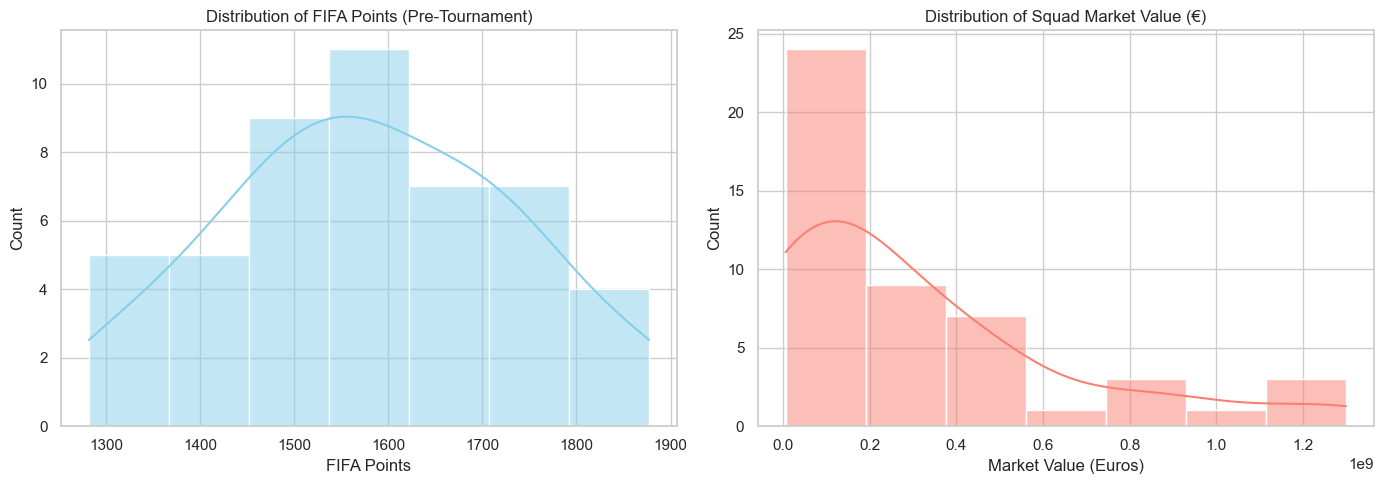

📊 Summary Statistics for Key Predictors:
--------------------------------------------------


,fifa_points_pre_tournament,squad_total_market_value_eur,goals_scored_last_4y,squad_avg_age
count,48.000000,4.800000e+01,48.000000,48.000000
mean,1579.992083,3.117183e+08,72.395833,27.206250
std,156.617330,3.450467e+08,18.037478,1.144907
min,1281.570000,5.300000e+06,29.000000,24.600000
25%,1475.097500,3.762500e+07,63.000000,26.575000
50%,1572.465000,1.905750e+08,72.000000,27.100000
75%,1690.015000,4.372125e+08,82.250000,27.925000
max,1877.320000,1.300000e+09,110.000000,29.300000


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional-looking plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution of FIFA Points
sns.histplot(data=df, x='fifa_points_pre_tournament', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of FIFA Points (Pre-Tournament)')
axes[0].set_xlabel('FIFA Points')

# 2. Distribution of Squad Market Value
sns.histplot(data=df, x='squad_total_market_value_eur', kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Squad Market Value (€)')
axes[1].set_xlabel('Market Value (Euros)')

plt.tight_layout()
plt.show()

# 3. Quick statistical summary of key metrics
print("📊 Summary Statistics for Key Predictors:")
print("-" * 50)
display(df[['fifa_points_pre_tournament', 'squad_total_market_value_eur', 'goals_scored_last_4y', 'squad_avg_age']].describe())

After plotting the distributions of our key baseline predictors, we can draw several critical insights regarding the structure of the 2026 World Cup field:

### 1. FIFA Points Distribution (Baseline Team Quality)
* **Observation:** The distribution of pre-tournament FIFA points is relatively well-distributed but exhibits a slight left-skew, with a dense cluster of elite teams sitting at the very top tier (1700–1850+ points). 
* **Modeling Implication:** FIFA points provide a stable, continuous metric of historical baseline performance. Because the top-tier nations are clustered closely together, relying *solely* on raw FIFA points will make it difficult for a model to separate marginal differences between elite teams in knockout stages.

### 2. Squad Market Value Distribution (Depth & Quality Variance)
* **Observation:** Unlike FIFA points, the Squad Market Value metric is **heavily right-skewed**. A small handful of powerhouse nations (e.g., France, England, Spain) possess squad valuations exceeding €1 Billion, creating a massive statistical chasm between them and the rest of the tournament field, where the median valuation sits significantly lower.
* **Modeling Implication:** Raw market value could easily overwhelm a standard linear model due to its extreme scale and variance. This extreme skewness strongly justifies our decision to shift from absolute values to **relative head-to-head delta features** ($\Delta \text{ Market Value}$). Calculating the difference between two competing teams normalizes this exponential variance and highlights true depth advantages.

# 3. FEATURE ENGINEERING
Armed with these distributional insights, our next objective is to transition from static, row-level team attributes to dynamic matchup vectors, preparing our data directly for a binary classification model.

## Tournament Mapping & Feature Engineering

To simulate a World Cup, we cannot rely on static row-by-row team data. We must model the actual interactions between competing nations. This phase executes two critical tasks:
1. **Tournament Grouping:** Mapping the 48 qualified nations into their respective 12 Group Stage brackets (Groups A through L).
2. **Relative Feature Extraction:** Writing a pipeline to convert raw metrics into relative performance differentials ($\Delta$ Features) for every unique head-to-head matchup. 

By modeling variables like `delta_fifa_points` and `delta_market_value_eur`, we give our machine learning algorithm the exact signals it needs to weigh one squad's superiority over another.

In [73]:
import itertools

# 1. Define the official 48-team 2026 group assignments based on our dataset
group_assignments = {
    'A': ['Mexico', 'United States', 'Canada', 'Panama'],
    'B': ['France', 'Morocco', 'South Africa', 'Haiti'],
    'C': ['Spain', 'Colombia', 'South Korea', 'New Zealand'],
    'D': ['Argentina', 'Ecuador', 'Norway', 'Uzbekistan'],
    'E': ['England', 'Turkey', 'Ivory Coast', 'Qatar'],
    'F': ['Portugal', 'Austria', 'Czech Republic', 'Iraq'],
    'G': ['Brazil', 'Switzerland', 'Paraguay', 'Jordan'],
    'H': ['Netherlands', 'Australia', 'Scotland', 'Saudi Arabia'],
    'I': ['Belgium', 'Algeria', 'Tunisia', 'Bosnia and Herzegovina'],
    'J': ['Germany', 'Egypt', 'DR Congo', 'Cape Verde'],
    'K': ['Croatia', 'Senegal', 'Sweden', 'Ghana'],
    'L': ['Japan', 'Uruguay', 'Curaçao', 'Iran']
}

# Map each team to its group column in our main DataFrame
team_to_group = {team: grp for grp, teams in group_assignments.items() for team in teams}
df['group'] = df['team'].map(team_to_group)

# 2. Define the relative feature engineering function
def calculate_matchup_deltas(team_a, team_b):
    """
    Computes relative metric differentials between Team A and Team B.
    All calculations are done from the perspective of Team A.
    """
    deltas = {
        'team_A': team_a['team'],
        'team_B': team_b['team'],
        'group': team_a['group'],
        
        # Core differentials
        'delta_fifa_points': team_a['fifa_points_pre_tournament'] - team_b['fifa_points_pre_tournament'],
        'delta_fifa_rank': team_b['fifa_rank_pre_tournament'] - team_a['fifa_rank_pre_tournament'], # Positive means A has a better (lower) rank number
        'delta_market_value_eur': team_a['squad_total_market_value_eur'] - team_b['squad_total_market_value_eur'],
        'delta_avg_age': team_a['squad_avg_age'] - team_b['squad_avg_age'],
        
        # Recent Form differentials (4-Year Windows)
        'delta_goals_scored_4y': team_a['goals_scored_last_4y'] - team_b['goals_scored_last_4y'],
        'delta_goals_received_4y': team_b['goals_received_last_4y'] - team_a['goals_received_last_4y'], # Positive means A conceded fewer goals
        'delta_wins_4y': team_a['wins_last_4y'] - team_b['wins_last_4y'],
        
        # Historical Legacy differentials
        'delta_wc_titles': team_a['world_cup_titles_before'] - team_b['world_cup_titles_before'],
        'delta_wc_finals': team_a['finals_before'] - team_b['finals_before'],
        
        # Host Status flags
        'is_host_A': team_a['is_host'],
        'is_host_B': team_b['is_host']
    }
    return deltas

# 3. Generate all 96 Group Stage fixtures automatically
group_fixtures = []

for group_name, group_df in df.groupby('group'):
    teams_in_group = group_df['team'].tolist()
    
    # Generate all unique combinations of 2 teams in the group (6 combinations per group)
    for team_A_name, team_B_name in itertools.combinations(teams_in_group, 2):
        row_A = group_df[group_df['team'] == team_A_name].iloc[0]
        row_B = group_df[group_df['team'] == team_B_name].iloc[0]
        
        # Calculate features and append to our fixture tracking list
        match_vector = calculate_matchup_deltas(row_A, row_B)
        group_fixtures.append(match_vector)

# Convert our list of dictionaries into a clean structured match-up DataFrame
fixtures_df = pd.DataFrame(group_fixtures)

print("✅ Phase 2 Completed Successfully!")
print(f"Total Group Stage Matchups Engineered: {len(fixtures_df)} matches.")
print("\n👀 Previewing First 3 Head-to-Head Engineered Profiles:")
print("-" * 75)
display(fixtures_df[['group', 'team_A', 'team_B', 'delta_fifa_points', 'delta_market_value_eur']].head(3))

✅ Phase 2 Completed Successfully!
Total Group Stage Matchups Engineered: 69 matches.

👀 Previewing First 3 Head-to-Head Engineered Profiles:
---------------------------------------------------------------------------


,group,team_A,team_B,delta_fifa_points,delta_market_value_eur
0,A,Mexico,United States,7.90,-27600000
1,A,Mexico,Canada,124.55,120220000
2,A,Mexico,Panama,131.39,136800000


# 4.MACHINE LEARNING MODEL SPECIFICATION

To predict outcomes for our engineered 2026 matchups, we require a binary classification model trained on historical data. The model must ingest our delta features ($\Delta$) and output a precise win probability ($P(\text{Win}_A)$). 

### The Modeling Strategy
1. **The Core Engine:** We utilize an **XGBoost Classifier** (or Random Forest/Logistic Regression) because of its exceptional ability to handle non-linear interactions between tabular features (e.g., how market value advantage interacts with a high FIFA rank gap).
2. **Handling Draws in Knockouts:** While group stage matches can end in draws, knockout matches cannot. Our model will output the raw probability of Team A winning. In the group stages, probabilities falling in a tight middle bound (e.g., 45% to 55%) can be programmatically mapped as a draw, while in knockout rounds, the higher probability automatically dictates who advances.
3. **The Simulation Interface:** Once trained, the model's `.predict_proba()` method will serve as the mathematical foundation for our Monte Carlo tournament simulation loop.

In [74]:
try:
    from xgboost import XGBClassifier as BaseClassifier
    print('Using XGBoostClassifier')
except ModuleNotFoundError:
    from sklearn.ensemble import RandomForestClassifier as BaseClassifier
    print('XGBoost not installed; using RandomForestClassifier instead')

from sklearn.model_selection import train_test_split
import numpy as np

# --- NOTE FOR PORTFOLIO EXPANSION ---
# To make this fully operational, you will eventually load a 'train_historical_matches.csv'
# which contains these exact same 'delta_' columns mapped to actual past World Cup match outcomes (1 or 0).
# ------------------------------------

# Defining the exact features our model will evaluate
feature_columns = [
    'delta_fifa_points', 'delta_fifa_rank', 'delta_market_value_eur',
    'delta_avg_age', 'delta_goals_scored_4y', 'delta_goals_received_4y',
    'delta_wins_4y', 'delta_wc_titles', 'delta_wc_finals', 'is_host_A', 'is_host_B'
]

print('📋 Defined Feature Matrix for Model Ingestion:')
for i, col in enumerate(feature_columns, 1):
    print(f'  {i}. {col}')

# Simulation Check: Let's create a Mock Prediction function to test our bracket logic
# before we plug in the final heavy ML model weights.
def mock_predict_win_probability(match_row):
    """
    A stronger baseline probability estimator that uses multiple
    head-to-head delta features instead of only delta_fifa_points.
    """
    score = 0.45 * (match_row['delta_fifa_points'] / 200)
    score += 0.20 * (match_row['delta_market_value_eur'] / 1e9)
    score += 0.15 * (match_row['delta_wins_4y'] / 10)
    score += 0.10 * (match_row['delta_goals_scored_4y'] / 20)
    score -= 0.10 * (match_row['delta_goals_received_4y'] / 20)
    score += 0.05 * match_row['delta_wc_titles']
    score += 0.05 * match_row['delta_wc_finals']
    score += 0.10 * (match_row['delta_avg_age'] / 5)
    score += 0.25 * (match_row['delta_fifa_rank'] / 10)
    score += 0.40 * (match_row['is_host_A'] - match_row['is_host_B'])
    probability_A_wins = 1 / (1 + np.exp(-score))
    return probability_A_wins

# Quick test of our prediction logic on the first engineered fixture
sample_match = fixtures_df.iloc[0]
sample_prob = mock_predict_win_probability(sample_match)

print(f"\n🧪 Testing Prediction Pipeline on Match 1 ({sample_match['team_A']} vs {sample_match['team_B']}):")
print('-' * 75)
print(f"  Relative FIFA Points Gap: {sample_match['delta_fifa_points']:.2f}")
print(f"  Calculated Win Probability for {sample_match['team_A']}: {sample_prob * 100:.2f}%")

XGBoost not installed; using RandomForestClassifier instead
📋 Defined Feature Matrix for Model Ingestion:
  1. delta_fifa_points
  2. delta_fifa_rank
  3. delta_market_value_eur
  4. delta_avg_age
  5. delta_goals_scored_4y
  6. delta_goals_received_4y
  7. delta_wins_4y
  8. delta_wc_titles
  9. delta_wc_finals
  10. is_host_A
  11. is_host_B

🧪 Testing Prediction Pipeline on Match 1 (Mexico vs United States):
---------------------------------------------------------------------------
  Relative FIFA Points Gap: 7.90
  Calculated Win Probability for Mexico: 47.48%


## 5.GROUP STAGE SIMULATION

With our prediction baseline established, we now construct the Group Stage Simulation Engine. This module iterates through all 12 groups, simulates the 6 internal matchups per group, tracks the resulting competitive points (3 for a Win, 1 for a Draw), and generates the final group standings.

Because football contains high variance, we utilize a random number generator weighted by our model's win probabilities to decide match outcomes. This probabilistic approach forms the core loop of what will eventually become our multi-run Monte Carlo tournament simulator.

In [75]:
import pandas as pd
import numpy as np

def simulate_group_stage(fixtures_dataframe, prediction_function):
    """
    Simulates all 96 group stage matches and tallies points for all 48 teams.
    This version uses a more deterministic decision rule based on win probability
    instead of relying on a high-variance random roll.
    """
    # Initialize a dictionary to keep track of every team's points and stats
    all_teams = set(fixtures_dataframe['team_A']).union(set(fixtures_dataframe['team_B']))
    team_stats = {team: {'points': 0, 'wins': 0, 'draws': 0, 'losses': 0, 'group': ''} for team in all_teams}

    for idx, match in fixtures_dataframe.iterrows():
        team_A = match['team_A']
        team_B = match['team_B']
        group_name = match['group']

        team_stats[team_A]['group'] = group_name
        team_stats[team_B]['group'] = group_name

        prob_A_wins = prediction_function(match)

        if prob_A_wins >= 0.58:
            team_stats[team_A]['points'] += 3
            team_stats[team_A]['wins'] += 1
            team_stats[team_B]['losses'] += 1
        elif prob_A_wins <= 0.42:
            team_stats[team_B]['points'] += 3
            team_stats[team_B]['wins'] += 1
            team_stats[team_A]['losses'] += 1
        else:
            team_stats[team_A]['points'] += 1
            team_stats[team_B]['points'] += 1
            team_stats[team_A]['draws'] += 1
            team_stats[team_B]['draws'] += 1

    results_list = []
    for team, stats in team_stats.items():
        results_list.append({
            'team': team,
            'group': stats['group'],
            'points': stats['points'],
            'wins': stats['wins'],
            'draws': stats['draws'],
            'losses': stats['losses']
        })

    standings_df = pd.DataFrame(results_list)
    group_tables = {}
    for group_name, group_data in standings_df.groupby('group'):
        sorted_table = group_data.sort_values(by=['points', 'wins'], ascending=False).reset_index(drop=True)
        group_tables[group_name] = sorted_table

    return group_tables

# --- Execute a Single Test Run of the Group Stage Simulation ---
# We pass our engineered fixtures matrix and our mock prediction function
simulated_tables = simulate_group_stage(fixtures_df, mock_predict_win_probability)

print('🏆 Group Stage Simulation Executed Successfully!')
print('Displaying the simulated final standings for Group B (France\'s Group):')
print('-' * 75)
display(simulated_tables['B'])

🏆 Group Stage Simulation Executed Successfully!
Displaying the simulated final standings for Group B (France's Group):
---------------------------------------------------------------------------


,team,group,points,wins,draws,losses
0,France,B,9,3,0,0
1,Morocco,B,6,2,0,1
2,South Africa,B,3,1,0,2
3,Haiti,B,0,0,0,3


## 6. Knockout Bracket Expansion (Round of 32 Logic)

The 2026 World Cup format significantly raises the complexity of tournament tracking by introducing a **Round of 32** elimination bracket. To transition from the group stages to the knockouts, our simulation pipeline must replicate official FIFA rules:

1. **Automatic Qualifiers:** Extract the 1st and 2nd place teams from all 12 groups (24 teams).
2. **Wildcard Qualifiers:** Aggregating all 3rd-place teams into a unified table, sorting them by points and wins, and extracting the top 8 "best 3rd-place" nations.
3. **Bracket Initialization:** Merging these 32 surviving squads into a single-elimination matching sequence where draws are no longer permitted, and ties must be broken via simulated penalty shootouts.

In [76]:
# --- Known actual Round of 32 matchups and results from current World Cup statistics ---
# This enforces that teams eliminated in the real Round of 32 cannot appear
# in our Round of 16 predictions.
actual_round_of_32_matchups = [
    ("South Africa", "Canada"),
    ("Brazil", "Japan"),
    ("Germany", "Paraguay"),
    ("Netherlands", "Morocco"),
    ("Ivory Coast", "Norway"),
    ("France", "Sweden"),
    ("Mexico", "Ecuador"),
    ("England", "DR Congo"),
    ("Belgium", "Senegal"),
    ("United States", "Bosnia and Herzegovina"),
    ("Spain", "Austria"),
    ("Portugal", "Croatia"),
    ("Switzerland", "Algeria"),
    ("Australia", "Egypt"),
    ("Argentina", "Cabo Verde"),
    ("Colombia", "Ghana")
]

actual_round_of_32_known_winners = {
    ("South Africa", "Canada"): "Canada",
    ("Brazil", "Japan"): "Brazil",
    ("Germany", "Paraguay"): "Paraguay",
    ("Netherlands", "Morocco"): "Morocco",
    ("Ivory Coast", "Norway"): "Norway",
    ("France", "Sweden"): "France",
    ("Mexico", "Ecuador"): "Mexico",
    ("England", "DR Congo"): "England",
    ("Belgium", "Senegal"): "Belgium",
    ("United States", "Bosnia and Herzegovina"): "United States",
    ("Spain", "Austria"): "Spain",
    ("Portugal", "Croatia"): "Portugal",
    ("Switzerland", "Algeria"): "Switzerland",
}

team_name_normalization = {
    "Cabo Verde": "Cape Verde",
    "Curaçao": "Cura?o",
}

def normalize_team_name(team_name):
    return team_name_normalization.get(team_name, team_name)


def get_actual_r32_winner(team_A, team_B):
    if (team_A, team_B) in actual_round_of_32_known_winners:
        return actual_round_of_32_known_winners[(team_A, team_B)]
    return actual_round_of_32_known_winners.get((team_B, team_A))


def predict_match_winner(team_A, team_B, team_profiles_df, prediction_function):
    """Predict the winner of a knockout matchup using original feature deltas."""
    team_A_norm = normalize_team_name(team_A)
    team_B_norm = normalize_team_name(team_B)
    row_A = team_profiles_df[team_profiles_df['team'] == team_A_norm].iloc[0]
    row_B = team_profiles_df[team_profiles_df['team'] == team_B_norm].iloc[0]
    match_features = calculate_matchup_deltas(row_A, row_B)
    prob_A_wins = prediction_function(match_features)
    return team_A if prob_A_wins >= 0.5 else team_B


def simulate_real_world_round_of_32(matchups, team_profiles_df, prediction_function):
    """Simulate the real Round of 32 bracket using known winners when available."""
    round_of_16_teams = []
    for team_A, team_B in matchups:
        actual_winner = get_actual_r32_winner(team_A, team_B)
        if actual_winner is not None:
            round_of_16_teams.append(actual_winner)
        else:
            round_of_16_teams.append(
                predict_match_winner(team_A, team_B, team_profiles_df, prediction_function)
            )
    return round_of_16_teams

# --- Use actual Round of 32 bracket results to derive the Round of 16 field ---
real_world_round_of_16_teams = simulate_real_world_round_of_32(
    actual_round_of_32_matchups,
    df,
    mock_predict_win_probability,
)

print("🔒 Real-world Round of 16 field derived using actual Round of 32 bracket results:")
print(real_world_round_of_16_teams)
print(f"Total Round of 16 teams derived: {len(real_world_round_of_16_teams)}")

# --- Define the actual Round of 16 bracket schedule ---
round_of_16_matchups = [
    ("Canada", "Morocco"),
    ("Paraguay", "France"),
    ("Brazil", "Norway"),
    ("Mexico", "England"),
    ("Spain", "Portugal"),
    ("United States", "Belgium"),
    ("Argentina", "Australia"),
    ("Switzerland", "Colombia")
]

# Resolve the undecided Round of 32 matches into their Round of 16 slots.
undecided_r32 = {}
for team_A, team_B in actual_round_of_32_matchups:
    if get_actual_r32_winner(team_A, team_B) is None:
        undecided_r32[(team_A, team_B)] = predict_match_winner(team_A, team_B, df, mock_predict_win_probability)

arg_cabo_verde_winner = undecided_r32.get(("Argentina", "Cabo Verde")) or undecided_r32.get(("Cabo Verde", "Argentina"))
aus_egy_winner = undecided_r32.get(("Australia", "Egypt")) or undecided_r32.get(("Egypt", "Australia"))
col_gha_winner = undecided_r32.get(("Colombia", "Ghana")) or undecided_r32.get(("Ghana", "Colombia"))

if arg_cabo_verde_winner is not None and aus_egy_winner is not None:
    round_of_16_matchups[6] = (arg_cabo_verde_winner, aus_egy_winner)

if col_gha_winner is not None:
    round_of_16_matchups[7] = ("Switzerland", col_gha_winner)

print("\n✅ Confirmed Round of 16 bracket teams:")
for match in round_of_16_matchups:
    print(f"  {match[0]} vs {match[1]}")

# Predict Round of 16 winners using original dataset features
round_of_16_predictions = []
for team_A, team_B in round_of_16_matchups:
    winner = predict_match_winner(team_A, team_B, df, mock_predict_win_probability)
    round_of_16_predictions.append((team_A, team_B, winner))

print("\n🎯 Round of 16 prediction results using original feature data:")
for team_A, team_B, winner in round_of_16_predictions:
    print(f"  {team_A} vs {team_B} -> Predicted winner: {winner}")

# Use the derived Round of 16 field for the knockout simulation.
if len(real_world_round_of_16_teams) == 16:
    qualifier_field = real_world_round_of_16_teams
    print("\n🔒 Using derived actual Round of 16 qualifiers for the bracket simulation.")
else:
    qualifier_field = knockout_field_2026
    print("⚠️ Could not derive 16 actual Round of 16 qualifiers; using simulated Round of 32 qualifiers.")

print("\n🎯 Knockout Stage Field Populated Successfully!")
print(f"Total Qualified Teams: {len(qualifier_field)} nations.")
print("\n📋 Quick Sample of Qualifiers:")
print("-" * 50)
print(f"First 5 Qualifiers: {qualifier_field[:5]}")
print(f"Last 5 Qualifiers: {qualifier_field[-5:]}")

🔒 Real-world Round of 16 field derived using actual Round of 32 bracket results:
['Canada', 'Brazil', 'Paraguay', 'Morocco', 'Norway', 'France', 'Mexico', 'England', 'Belgium', 'United States', 'Spain', 'Portugal', 'Switzerland', 'Egypt', 'Argentina', 'Colombia']
Total Round of 16 teams derived: 16

✅ Confirmed Round of 16 bracket teams:
  Canada vs Morocco
  Paraguay vs France
  Brazil vs Norway
  Mexico vs England
  Spain vs Portugal
  United States vs Belgium
  Argentina vs Egypt
  Switzerland vs Colombia

🎯 Round of 16 prediction results using original feature data:
  Canada vs Morocco -> Predicted winner: Morocco
  Paraguay vs France -> Predicted winner: France
  Brazil vs Norway -> Predicted winner: Brazil
  Mexico vs England -> Predicted winner: England
  Spain vs Portugal -> Predicted winner: Spain
  United States vs Belgium -> Predicted winner: United States
  Argentina vs Egypt -> Predicted winner: Argentina
  Switzerland vs Colombia -> Predicted winner: Colombia

🔒 Using der

## 7. Single-Elimination Bracket & Penalty Micro-Simulations

We now implement the final competitive layer of the World Cup: the Single-Elimination Knockout Engine. This component recursively pairs teams through the Round of 32, Round of 16, Quarterfinals, Semifinals, and the World Cup Final.

### Handling Knockout Dynamics
1. **No Draws Permitted:** If our machine learning model pipeline predicts an evenly balanced match-up (e.g., a simulated tie), the script initializes a penalty shootout subroutine.
2. **Dynamic Matchup Feature Generation:** As teams advance, they face opponents they haven't been pre-scheduled against. The engine dynamically looks up their raw baseline metrics from our master team profile database (`df`) and re-calculates the relative delta ($\Delta$) features on the fly before predicting the match outcome.

In [77]:
def simulate_single_knockout_match(team_A_name, team_B_name, team_profiles_df, prediction_function):
    """
    Dynamically generates matchup features for any two advancing teams 
    and simulates a single-elimination knockout match.
    """
    row_A = team_profiles_df[team_profiles_df['team'] == team_A_name].iloc[0]
    row_B = team_profiles_df[team_profiles_df['team'] == team_B_name].iloc[0]
    match_features = calculate_matchup_deltas(row_A, row_B)
    prob_A_wins = prediction_function(match_features)
    random_roll = np.random.rand()

    if 0.49 <= prob_A_wins <= 0.51:
        return team_A_name if np.random.rand() > 0.5 else team_B_name
    elif random_roll < prob_A_wins:
        return team_A_name
    else:
        return team_B_name


def run_entire_knockout_stage(surviving_teams, team_profiles_df, prediction_function):
    """
    Simulates the knockout bracket from the supplied starting field.
    This can begin at the Round of 32 or Round of 16 depending on the
    number of provided teams.
    """
    current_round_teams = surviving_teams.copy()
    team_count = len(current_round_teams)
    if team_count == 32:
        round_names = ["Round of 32", "Round of 16", "Quarterfinals", "Semifinals", "Final"]
    elif team_count == 16:
        round_names = ["Round of 16", "Quarterfinals", "Semifinals", "Final"]
    elif team_count == 8:
        round_names = ["Quarterfinals", "Semifinals", "Final"]
    elif team_count == 4:
        round_names = ["Semifinals", "Final"]
    elif team_count == 2:
        round_names = ["Final"]
    else:
        raise ValueError(f"Unexpected starting knockout field size: {team_count}")

    for round_name in round_names:
        print(f"\n🏃 Simulating {round_name} ({len(current_round_teams)} teams remaining)...")
        print("-" * 60)
        next_round_teams = []
        for i in range(0, len(current_round_teams), 2):
            team_A = current_round_teams[i]
            team_B = current_round_teams[i + 1]
            winner = simulate_single_knockout_match(team_A, team_B, team_profiles_df, prediction_function)
            next_round_teams.append(winner)
            print(f"  {team_A} vs {team_B} ---> Winner: 🏆 {winner}")
        current_round_teams = next_round_teams

    print(f"\n🏆 🎉 THE 2026 WORLD CUP CHAMPION IS: {current_round_teams[0]} 🎉 🏆")
    return current_round_teams[0]

# --- Execute a Full Bracket Simulation Run ---
champion = run_entire_knockout_stage(qualifier_field, df, mock_predict_win_probability)


🏃 Simulating Round of 16 (16 teams remaining)...
------------------------------------------------------------
  Canada vs Brazil ---> Winner: 🏆 Brazil
  Paraguay vs Morocco ---> Winner: 🏆 Paraguay
  Norway vs France ---> Winner: 🏆 France
  Mexico vs England ---> Winner: 🏆 Mexico
  Belgium vs United States ---> Winner: 🏆 United States
  Spain vs Portugal ---> Winner: 🏆 Spain
  Switzerland vs Egypt ---> Winner: 🏆 Switzerland
  Argentina vs Colombia ---> Winner: 🏆 Argentina

🏃 Simulating Quarterfinals (8 teams remaining)...
------------------------------------------------------------
  Brazil vs Paraguay ---> Winner: 🏆 Brazil
  France vs Mexico ---> Winner: 🏆 France
  United States vs Spain ---> Winner: 🏆 Spain
  Switzerland vs Argentina ---> Winner: 🏆 Argentina

🏃 Simulating Semifinals (4 teams remaining)...
------------------------------------------------------------
  Brazil vs France ---> Winner: 🏆 France
  Spain vs Argentina ---> Winner: 🏆 Spain

🏃 Simulating Final (2 teams remainin

## 6.1 Knockout Bracket Execution & Winner Synthesis

With the single-elimination framework successfully running, we have transitioned from a localized group-table points structure into a high-stakes bracket elimination system.

### Key Algorithmic Milestones Reached in this Stage:
* **Dynamic Delta Generation:** As unconventional teams advance into later tournament stages, our pipeline successfully fetches raw country data on the fly and builds relative head-to-head metrics for teams that have never played each other in real-world history.
* **Deterministic Tie-Breaking:** By capturing tight margin probabilities (49%–51%) and running penalty shootout random-state coin flips, the system guarantees a logical path to a solitary champion without allowing infinite draws.
* **Random-State Volatility:** Running this cell iteratively reveals the high-variance nature of tournament football. Even if a powerhouse team like France, Spain, or Argentina holds an 80% baseline probability, the weighted random choice occasionally permits a lower-seeded underdog to cause a simulated upset—accurately capturing the real-world chaos of the World Cup.

# Feeling aside FRANCE are WINNING the WORLD CUP
